# IY036 – Benchmarking the pretrained SupCon checkpoints

**Goal:** score every SupCon checkpoint trained in IY036 on the *same* 6-class
TF@condition benchmark IY031/IY032 used, so the label-supervised contrastive
models are row-comparable with the self-supervised SimCLR ones.

**Benchmark split:** `prepare_dataset` on the 6 fixed IY021 classes — balanced to
78 cells/class, stratified 80/20 → 374 train / 94 test. This is the split IY031
(SVM readout) and IY032 (KNN readout) were measured on, and the split the v1/v4
training scripts held their test cells out of.

**Readouts** (both reported for every checkpoint):
- **SVM** — encode → `StandardScaler` on embeddings → RBF-SVM (IY031 protocol)
- **KNN** — encode → k=10 Euclidean KNN on *raw* embeddings (IY032 protocol)

**Baselines:** Raw SVM / Raw KNN on the flat traces, Catch22 + SVM / KNN, and the
best SimCLR checkpoint from IY031 (SVM) and IY032 (KNN), read from their result
CSVs rather than re-run.

**Leakage caveat (section 6):** v2 and v3 were trained on a *different* split
(`prepare_split_dataset`, 60/20/20, unbalanced). Their pretraining pool therefore
contains cells that are in *this* notebook's test set, seen **with their labels**
during supervised contrastive training. Section 6 measures that overlap exactly;
those checkpoints are flagged and excluded from every "best model" claim.

**Excluded:** experiment 18446 (not properly recorded).

In [20]:
import re
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from pathlib import Path
from matplotlib.patches import Patch
from IPython.display import display
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

sys.path.insert(0, str(Path("/home/ianyang/stochastic_simulations/src").resolve()))
from models.ssl_transformer import SSL_Transformer

RANDOM_STATE = 42
K_NEIGHBORS  = 10    # IY032's grid-searched k, reused by every IY036 training script
SEQ_LEN      = 540   # trace length every IY036 checkpoint was trained on

# Fixed 6-class selection: Nrg1 and Rtg1 at the 3 glucose conditions used in IY021
FIXED_CLASSES = [
    "Nrg1 @ 0.01% glucose",
    "Nrg1 @ 0.1% glucose",
    "Nrg1 @ 2% glucose (mock/steady)",
    "Rtg1 @ 0.01% glucose",
    "Rtg1 @ 0.1% glucose",
    "Rtg1 @ 2% glucose (mock/steady)",
]

EXP_DIR       = Path("/home/ianyang/stochastic_simulations/experiments")
IY036_DIR     = EXP_DIR / "EXP-26-IY036"
IY031_DIR     = EXP_DIR / "EXP-26-IY031"
IY032_DIR     = EXP_DIR / "EXP-26-IY032"
IY008_DIR     = EXP_DIR / "EXP-25-IY008"
SS_DATA_DIR   = IY008_DIR / "4_transformed_exp_time_series"
FULL_DATA_DIR = IY008_DIR / "5_FULL_transformed_exp_time_series"
META_PATH     = IY008_DIR / "old_data_metadata.csv"
META_COLS     = ["id", "group", "experiment"]

EXCLUDED_EXPS = {"18446"}
FILE_RE       = re.compile(r"^(\d+)_.*_group_(.+?)_(GFP|mCherry)_time_series$")
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
plt.rcParams.update({
    "font.family": "sans-serif", "axes.titlesize": 14,
    "axes.labelsize": 12, "xtick.labelsize": 10,
    "ytick.labelsize": 10, "legend.fontsize": 10,
})
sns.set_theme(style="whitegrid", palette="colorblind")
print(f"Device: {DEVICE}")

Device: cuda


## 1. Metadata & Label Lookup

In [21]:
metadata = pd.read_csv(META_PATH)
metadata["exp_id"]   = metadata["exp_id"].astype(str)
metadata["group_id"] = metadata["group_id"].astype(str)

LABEL_LOOKUP = {
    (row.exp_id, row.group_id, row.channel): (row.tf, row.condition)
    for _, row in metadata.iterrows()
}

print(f"Metadata entries: {len(LABEL_LOOKUP)}")
print("Unique TFs:",        sorted(metadata["tf"].unique()))
print("Unique conditions:", sorted(metadata["condition"].unique()))

Metadata entries: 66
Unique TFs: ['Cat8', 'Dot6', 'Maf1', 'Mig1', 'Mig2', 'Msn2', 'Nrg1', 'Rtg1', 'Sfp1', 'Tod6']
Unique conditions: ['0.01% galactose', '0.01% glucose', '0.1% glucose', '2% galactose', '2% glucose (mock/steady)']


## 2. Load Datasets

Both the steady-state (80 tp) and full (540 tp) versions are loaded. The IY036
checkpoints were trained on 540-tp traces, so **Full is the headline dataset**;
steady-state is retained as a length-generalisation check (the backbone mean-pools
over time, so it accepts any length).

In [22]:
from utils.experimental_time_series import load_labelled_time_series_csvs


def load_dataset(data_dir: Path):
    """Scan data_dir for time-series CSVs; assign TF@condition labels via metadata."""
    return load_labelled_time_series_csvs(
        data_dir=data_dir,
        file_re=FILE_RE,
        label_lookup=LABEL_LOOKUP,
        meta_cols=META_COLS,
        excluded_exps=EXCLUDED_EXPS,
        verbose=False,
    )


ss_ts_raw,   ss_label_strs   = load_dataset(SS_DATA_DIR)
full_ts_raw, full_label_strs = load_dataset(FULL_DATA_DIR)
print(f"Steady-state: {len(ss_label_strs)} cells from {len(ss_ts_raw)} files")
print(f"Full        : {len(full_label_strs)} cells from {len(full_ts_raw)} files")

Steady-state: 11980 cells from 66 files
Full        : 11980 cells from 66 files


## 3. Class Selection

In [23]:
def print_class_summary(label_strs, kept_classes, dataset_name):
    counts = pd.Series(label_strs).value_counts().sort_index()
    print(f"{dataset_name} -- {len(counts)} total classes, {len(label_strs)} total cells")
    for cls in sorted(kept_classes):
        print(f"  {cls:50s}: {counts.get(cls, 0):5d}")
    missing = [c for c in kept_classes if counts.get(c, 0) == 0]
    if missing:
        print(f"  WARNING: missing classes with no data: {missing}")
    print(f"  -> Using {len(kept_classes)} classes, chance = {1/len(kept_classes):.4f}")
    return list(kept_classes)


ss_kept_classes   = print_class_summary(ss_label_strs,   FIXED_CLASSES, "Steady-state")
print()
full_kept_classes = print_class_summary(full_label_strs, FIXED_CLASSES, "Full")

Steady-state -- 32 total classes, 11980 total cells
  Nrg1 @ 0.01% glucose                              :   231
  Nrg1 @ 0.1% glucose                               :   231
  Nrg1 @ 2% glucose (mock/steady)                   :    84
  Rtg1 @ 0.01% glucose                              :   275
  Rtg1 @ 0.1% glucose                               :   200
  Rtg1 @ 2% glucose (mock/steady)                   :    78
  -> Using 6 classes, chance = 0.1667

Full -- 32 total classes, 11980 total cells
  Nrg1 @ 0.01% glucose                              :   231
  Nrg1 @ 0.1% glucose                               :   231
  Nrg1 @ 2% glucose (mock/steady)                   :    84
  Rtg1 @ 0.01% glucose                              :   275
  Rtg1 @ 0.1% glucose                               :   200
  Rtg1 @ 2% glucose (mock/steady)                   :    78
  -> Using 6 classes, chance = 0.1667


## 4. Preprocessing

In [24]:
from utils.processing.pipeline import prepare_dataset

print("--- Steady-state ---")
ss = prepare_dataset(ss_ts_raw, ss_label_strs, ss_kept_classes, "Steady-state", RANDOM_STATE)
print()
print("--- Full ---")
full = prepare_dataset(full_ts_raw, full_label_strs, full_kept_classes, "Full", RANDOM_STATE)

DATASETS = {"Steady-state": ss, "Full": full}
N_TEST   = len(full["y_test"])
CHANCE   = 1.0 / len(full["class_names"])


def binomial_se(acc, n=N_TEST):
    """Standard error of a test accuracy, treating the n test calls as Bernoulli
    trials -- the only error bar available from a single held-out split."""
    return float(np.sqrt(acc * (1.0 - acc) / n))

--- Steady-state ---
Steady-state: 1099 cells × 80 tp, 6 classes, NaN remaining: 0
  Balancing to 78 cells/class
  Train: 374  |  Test: 94

--- Full ---
Full: 1099 cells × 540 tp, 6 classes, NaN remaining: 0
  Balancing to 78 cells/class
  Train: 374  |  Test: 94


## 5. Baselines

Raw and Catch22 features with both readouts, so every IY036 checkpoint has a
like-for-like reference under both SVM and KNN. Raw SVM / Catch22+SVM should
reproduce IY031's numbers exactly — a check that the split is byte-identical.

In [25]:
from features.catch22 import extract_catch22, fill_feature_frame


def run_raw_baselines(d, dataset_tag):
    """RBF-SVM and k=10 KNN on the flat, un-normalised traces (scaled in-pipeline)."""
    out = {}
    for name, clf in [("Raw SVM", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE)),
                      ("Raw KNN", KNeighborsClassifier(n_neighbors=K_NEIGHBORS, n_jobs=-1))]:
        pipe = Pipeline([("scaler", StandardScaler()), ("clf", clf)])
        pipe.fit(d["X_train_raw"], d["y_train"])
        y_pred = pipe.predict(d["X_test_raw"])
        acc = accuracy_score(d["y_test"], y_pred)
        out[name] = (acc, y_pred)
        print(f"  {name:12s} {dataset_tag:13s} acc={acc:.4f}")
    return out


CATCH22_FEATURES = {}   # dataset -> (train features, test features), reused by section 9


def run_catch22_baselines(d, dataset_tag):
    """Extract catch22 ONCE per split, then fit both readouts on the same features."""
    F_tr = extract_catch22(d["X_train_raw"], desc=f"catch22 train ({dataset_tag})")
    F_te = extract_catch22(d["X_test_raw"],  desc=f"catch22 test ({dataset_tag})")
    F_tr, F_te = fill_feature_frame(F_tr, F_te)
    CATCH22_FEATURES[dataset_tag] = (F_tr, F_te)
    out = {}
    for name, clf in [("Catch22+SVM", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE)),
                      ("Catch22+KNN", KNeighborsClassifier(n_neighbors=K_NEIGHBORS, n_jobs=-1))]:
        pipe = Pipeline([("scaler", StandardScaler()), ("clf", clf)])
        pipe.fit(F_tr, d["y_train"])
        y_pred = pipe.predict(F_te)
        acc = accuracy_score(d["y_test"], y_pred)
        out[name] = (acc, y_pred)
        print(f"  {name:12s} {dataset_tag:13s} acc={acc:.4f}")
    return out


BASELINES = {}
for tag, d in DATASETS.items():
    BASELINES[tag] = {**run_raw_baselines(d, tag), **run_catch22_baselines(d, tag)}

  Raw SVM      Steady-state  acc=0.7021
  Raw KNN      Steady-state  acc=0.6064


  Catch22+SVM  Steady-state  acc=0.3936
  Catch22+KNN  Steady-state  acc=0.2979


  Raw SVM      Full          acc=0.7553
  Raw KNN      Full          acc=0.7553


catch22 train (Full):   0%|          | 0/374 [00:00<?, ?it/s]

  Catch22+SVM  Full          acc=0.5426
  Catch22+KNN  Full          acc=0.5000


In [26]:
# Best SimCLR reference: IY031 (SVM readout) and IY032 (KNN readout) scored the
# same 34 checkpoints on this same split, so their CSVs are read rather than re-run.
SIMCLR_REF_CSVS = {
    ("Steady-state", "SVM"): IY031_DIR / "IY031_tf_condition_ss_simclr_results.csv",
    ("Full",         "SVM"): IY031_DIR / "IY031_tf_condition_full_simclr_results.csv",
    ("Steady-state", "KNN"): IY032_DIR / "IY032_tf_condition_ss_simclr_results.csv",
    ("Full",         "KNN"): IY032_DIR / "IY032_tf_condition_full_simclr_results.csv",
}

SIMCLR_REF = {}
for key, path in SIMCLR_REF_CSVS.items():
    ref = pd.read_csv(path).query("status == 'ok'").nlargest(1, "accuracy").iloc[0]
    # the checkpoint path is kept so section 9 can project the winning SimCLR embedding
    SIMCLR_REF[key] = {"accuracy": float(ref["accuracy"]), "label": ref["label"],
                       "checkpoint": ref["checkpoint"]}
    print(f"Best SimCLR {key[1]} -- {key[0]:13s}: {ref['accuracy']:.4f}  ({ref['label']})")

# Sanity check: the raw/catch22 SVM baselines must reproduce IY031's, or the split moved.
for tag, expected in [("Steady-state", 0.7021), ("Full", 0.7553)]:
    got = BASELINES[tag]["Raw SVM"][0]
    assert abs(got - expected) < 5e-4, f"Raw SVM {tag}: {got:.4f} != IY031's {expected:.4f}"
print("\nSplit check: Raw SVM reproduces IY031's accuracies -- benchmark split is identical.")

Best SimCLR SVM -- Steady-state : 0.6915  (IY022-global b64 D16 142010)
Best SimCLR SVM -- Full         : 0.7979  (IY017-inst b512 D16 154043)
Best SimCLR KNN -- Steady-state : 0.7340  (IY023-batch b64 D16 104312)
Best SimCLR KNN -- Full         : 0.8298  (IY017-inst b512 D16 154043)

Split check: Raw SVM reproduces IY031's accuracies -- benchmark split is identical.


## 6. IY036 Checkpoint Registry & Leakage Audit

The training script that produced a checkpoint is recorded only in its filename,
so `VARIANT_SPECS` maps filename prefix → variant, augmentation and split scheme.
Everything else (batch size, lr, timestamp, seed) is parsed from the name.

**Why the split scheme matters.** v1 and v4 built their SupCon pretraining pool by
excluding this notebook's 94 test cells. v2 and v3 used `prepare_split_dataset`
(60/20/20, unbalanced), whose train split overlaps this notebook's test set — and
SupCon is *label*-supervised, so any overlapping cell was pulled towards its class
centroid during pretraining. The next cell reconstructs the v2/v3 pretraining pool
and counts the overlap exactly instead of assuming it.

In [27]:
# filename prefix -> (variant, augmentation, split scheme used for its pretraining pool)
VARIANT_SPECS = [
    ("IY036_v4_winslice",        "v4", "winslice", "v1-balanced"),
    ("IY036_v3_composed",        "v3", "composed", "v2-60/20/20"),
    ("IY036_v3_jitter_only",     "v3", "jitter",   "v2-60/20/20"),
    ("IY036_v2_supcon_allclass", "v2", "jitter",   "v2-60/20/20"),
    ("IY036_supcon_allclass",    "v1", "jitter",   "v1-balanced"),
]
# The split this notebook evaluates on; checkpoints trained under any other scheme
# have seen some of these test cells (quantified below).
EVAL_SPLIT_SCHEME = "v1-balanced"


def describe_checkpoint(path: Path) -> dict:
    """Parse variant, augmentation, hyperparameters and run id out of a filename."""
    stem = path.stem
    spec = next((s for s in VARIANT_SPECS if stem.startswith(s[0])), None)
    if spec is None:
        raise ValueError(f"no VARIANT_SPECS entry matches {stem}")
    _, variant, augmentation, split_scheme = spec

    batch = int(re.search(r"_b(\d+)", stem).group(1))
    lr    = float(re.search(r"_lr([\d.]+)_", stem).group(1))
    stamp = re.search(r"_(20\d{6}_\d{6})", stem).group(1)
    seed  = re.search(r"_seed(\d+)", stem)
    seed  = int(seed.group(1)) if seed else RANDOM_STATE

    # short but unique: the time-of-day suffix separates same-config runs
    label = f"{variant}-{augmentation} b{batch} lr{lr} {stamp[-6:]}"
    if seed != RANDOM_STATE:
        label += f" s{seed}"
    return {
        "label": label, "variant": variant, "augmentation": augmentation,
        "split_scheme": split_scheme, "batch_size": batch, "lr": lr,
        "timestamp": stamp, "seed": seed,
        "eval_split_clean": split_scheme == EVAL_SPLIT_SCHEME,
        "checkpoint": str(path), "checkpoint_name": path.name,
    }


MODEL_REGISTRY = [describe_checkpoint(p) for p in sorted(IY036_DIR.glob("IY036_*_model.pth"))]
registry_df = pd.DataFrame(MODEL_REGISTRY).sort_values(["variant", "batch_size", "timestamp"])

print(f"Found {len(MODEL_REGISTRY)} IY036 checkpoints "
      f"({sum(r['eval_split_clean'] for r in MODEL_REGISTRY)} on this notebook's split)")
display(registry_df[["label", "variant", "augmentation", "batch_size", "lr",
                     "timestamp", "seed", "split_scheme", "eval_split_clean"]]
        .reset_index(drop=True))

Found 10 IY036 checkpoints (6 on this notebook's split)


,label,variant,augmentation,batch_size,lr,timestamp,seed,split_scheme,eval_split_clean
0,v1-jitter b512 lr0.001 112748,v1,jitter,512,0.001,20260727_112748,42,v1-balanced,True
1,v1-jitter b2048 lr0.001 123834,v1,jitter,2048,0.001,20260727_123834,42,v1-balanced,True
2,v1-jitter b2048 lr2.4 175732,v1,jitter,2048,2.400,20260727_175732,42,v1-balanced,True
3,v1-jitter b4096 lr4.8 142748,v1,jitter,4096,4.800,20260728_142748,42,v1-balanced,True
4,v2-jitter b4096 lr4.8 191805,v2,jitter,4096,4.800,20260729_191805,42,v2-60/20/20,False
5,v3-composed b4096 lr4.8 170044,v3,composed,4096,4.800,20260730_170044,42,v2-60/20/20,False
6,v3-jitter b4096 lr4.8 170059,v3,jitter,4096,4.800,20260730_170059,42,v2-60/20/20,False
7,v3-jitter b4096 lr4.8 170059 s43,v3,jitter,4096,4.800,20260730_170059,43,v2-60/20/20,False
8,v4-winslice b512 lr0.001 165501,v4,winslice,512,0.001,20260802_165501,42,v1-balanced,True
9,v4-winslice b4096 lr4.8 170659,v4,winslice,4096,4.800,20260802_170659,42,v1-balanced,True


In [28]:
from utils.processing.pipeline import prepare_split_dataset

# Reconstruct the v2/v3 pretraining pool (benchmark TRAIN cells + all non-benchmark
# cells) with the exact arguments those scripts used, then count how many of THIS
# notebook's test cells it contains. Traces are matched on raw bytes: both pools
# come from the same imputation pass at the same length, so equality is exact.
d_v2 = prepare_split_dataset(
    full_ts_raw, full_label_strs, FIXED_CLASSES, "Full (v2/v3 scheme)",
    random_state=RANDOM_STATE, val_fraction=0.20, test_fraction=0.20,
    balance=False, seq_len=SEQ_LEN, return_rest=True,
)
v2_pool = np.vstack([d_v2["X_train_raw"], d_v2["X_rest_raw"]]).astype(np.float64)
v2_pool_hashes = {row.tobytes() for row in v2_pool}

SEEN_IN_PRETRAINING = {
    "v1-balanced": 0,  # v1/v4 excluded these cells by construction (asserted in their scripts)
    "v2-60/20/20": sum(row.tobytes() in v2_pool_hashes
                       for row in full["X_test_raw"].astype(np.float64)),
}
n_leaked = SEEN_IN_PRETRAINING["v2-60/20/20"]
print(f"\nLeakage audit: {n_leaked}/{N_TEST} ({n_leaked / N_TEST:.0%}) of this notebook's "
      f"test cells were in the v2/v3 SupCon pretraining pool, with their labels.")
print("-> v2/v3 accuracies below are upward-biased and are excluded from best-model claims.")

Full (v2/v3 scheme): 1099 cells × 540 tp, 6 classes, NaN remaining: 0
  Train: 659  |  Val: 220  |  Test: 220
  Rest (non-benchmark): 10881 cells, 26 classes

Leakage audit: 59/94 (63%) of this notebook's test cells were in the v2/v3 SupCon pretraining pool, with their labels.
-> v2/v3 accuracies below are upward-biased and are excluded from best-model claims.


## 7. Score Every Checkpoint

One encode pass per checkpoint per dataset feeds both readouts: the SVM sees
`StandardScaler`-ed embeddings (IY031), the KNN sees raw embeddings (IY032 — an
IY035 ablation found embedding scaling homogenises checkpoints).

In [29]:
from utils.embeddings import load_simclr_model, encode_channel, fit_predict_knn


def run_readouts(model, d, device):
    """Encode once, then score both readouts. Returns {readout: (accuracy, y_pred)}."""
    Z_tr = encode_channel(model, d["X_train"], device)
    Z_te = encode_channel(model, d["X_test"],  device)

    sc = StandardScaler().fit(Z_tr)
    svm = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE)
    svm.fit(sc.transform(Z_tr), d["y_train"])
    y_svm = svm.predict(sc.transform(Z_te))

    y_knn = fit_predict_knn(Z_tr, d["y_train"], Z_te,
                            n_neighbors=K_NEIGHBORS, metric="euclidean")
    return {"SVM": (accuracy_score(d["y_test"], y_svm), y_svm),
            "KNN": (accuracy_score(d["y_test"], y_knn), y_knn)}


rows, PREDICTIONS = [], {}
for dataset_tag, d in DATASETS.items():
    print(f"=== {dataset_tag} (T={d['min_T']}, chance={1/len(d['class_names']):.4f}) ===")
    for row in MODEL_REGISTRY:
        record = {k: v for k, v in row.items() if k != "checkpoint"}
        record.update(dataset=dataset_tag, checkpoint=row["checkpoint"],
                      n_test=len(d["y_test"]), chance=1 / len(d["class_names"]),
                      test_cells_seen_in_pretraining=SEEN_IN_PRETRAINING[row["split_scheme"]])
        try:
            model = load_simclr_model(row["checkpoint"], DEVICE)
            res = run_readouts(model, d, DEVICE)
            PREDICTIONS[(dataset_tag, row["label"])] = {k: v[1] for k, v in res.items()}
            record.update(svm_accuracy=res["SVM"][0], knn_accuracy=res["KNN"][0], status="ok", error="")
            flag = "" if row["eval_split_clean"] else "  [leaky]"
            print(f"  {row['label']:<34s} SVM={res['SVM'][0]:.4f}  KNN={res['KNN'][0]:.4f}{flag}")
        except Exception as exc:
            record.update(svm_accuracy=np.nan, knn_accuracy=np.nan, status="failed", error=str(exc))
            print(f"  {row['label']:<34s} FAILED: {exc}")
        rows.append(record)

results_df = pd.DataFrame(rows)
results_csv = IY036_DIR / "IY036_benchmark_results.csv"
results_df.to_csv(results_csv, index=False)
print(f"\nSaved: {results_csv}")

=== Steady-state (T=80, chance=0.1667) ===


  v1-jitter b2048 lr0.001 123834     SVM=0.7021  KNN=0.6489


  v1-jitter b2048 lr2.4 175732       SVM=0.6702  KNN=0.6064


  v1-jitter b4096 lr4.8 142748       SVM=0.6596  KNN=0.6064


  v1-jitter b512 lr0.001 112748      SVM=0.6915  KNN=0.6596


...

  v3-composed b4096 lr4.8 170044     SVM=0.8085  KNN=0.7872  [leaky]


  v3-jitter b4096 lr4.8 170059       SVM=0.7979  KNN=0.7766  [leaky]


  v3-jitter b4096 lr4.8 170059 s43   SVM=0.8404  KNN=0.8191  [leaky]


  v4-winslice b4096 lr4.8 170659     SVM=0.8085  KNN=0.7766


  v4-winslice b512 lr0.001 165501    SVM=0.8085  KNN=0.8298

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY036/IY036_benchmark_results.csv


In [30]:
# Ranked view of the clean (v1/v4) checkpoints on the Full dataset -- the headline table.
clean_full = (results_df
              .query("dataset == 'Full' and status == 'ok' and eval_split_clean")
              .sort_values("svm_accuracy", ascending=False))
display(clean_full[["label", "variant", "augmentation", "batch_size", "lr",
                    "svm_accuracy", "knn_accuracy"]].round(4).reset_index(drop=True))

leaky_full = (results_df
              .query("dataset == 'Full' and status == 'ok' and not eval_split_clean")
              .sort_values("svm_accuracy", ascending=False))
print("\nv2/v3 checkpoints (upward-biased -- see section 6):")
display(leaky_full[["label", "variant", "augmentation", "svm_accuracy", "knn_accuracy",
                    "test_cells_seen_in_pretraining"]].round(4).reset_index(drop=True))

,label,variant,augmentation,batch_size,lr,svm_accuracy,knn_accuracy
0,v1-jitter b2048 lr2.4 175732,v1,jitter,2048,2.400,0.8511,0.8404
1,v1-jitter b512 lr0.001 112748,v1,jitter,512,0.001,0.8298,0.8298
2,v1-jitter b2048 lr0.001 123834,v1,jitter,2048,0.001,0.8191,0.8191
3,v1-jitter b4096 lr4.8 142748,v1,jitter,4096,4.800,0.8191,0.7660
4,v4-winslice b4096 lr4.8 170659,v4,winslice,4096,4.800,0.8085,0.7766
5,v4-winslice b512 lr0.001 165501,v4,winslice,512,0.001,0.8085,0.8298



v2/v3 checkpoints (upward-biased -- see section 6):


,label,variant,augmentation,svm_accuracy,knn_accuracy,test_cells_seen_in_pretraining
0,v3-jitter b4096 lr4.8 170059 s43,v3,jitter,0.8404,0.8191,59
1,v3-composed b4096 lr4.8 170044,v3,composed,0.8085,0.7872,59
2,v3-jitter b4096 lr4.8 170059,v3,jitter,0.7979,0.7766,59
3,v2-jitter b4096 lr4.8 191805,v2,jitter,0.7553,0.7766,59


## 8. Results

Error bars are the binomial standard error of a test accuracy,
$\sqrt{p(1-p)/n}$ with $n = 94$ — the only spread available from a single
held-out split, and worth reading before calling any two checkpoints different.

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY036/IY036_benchmark_checkpoint_accuracy.png


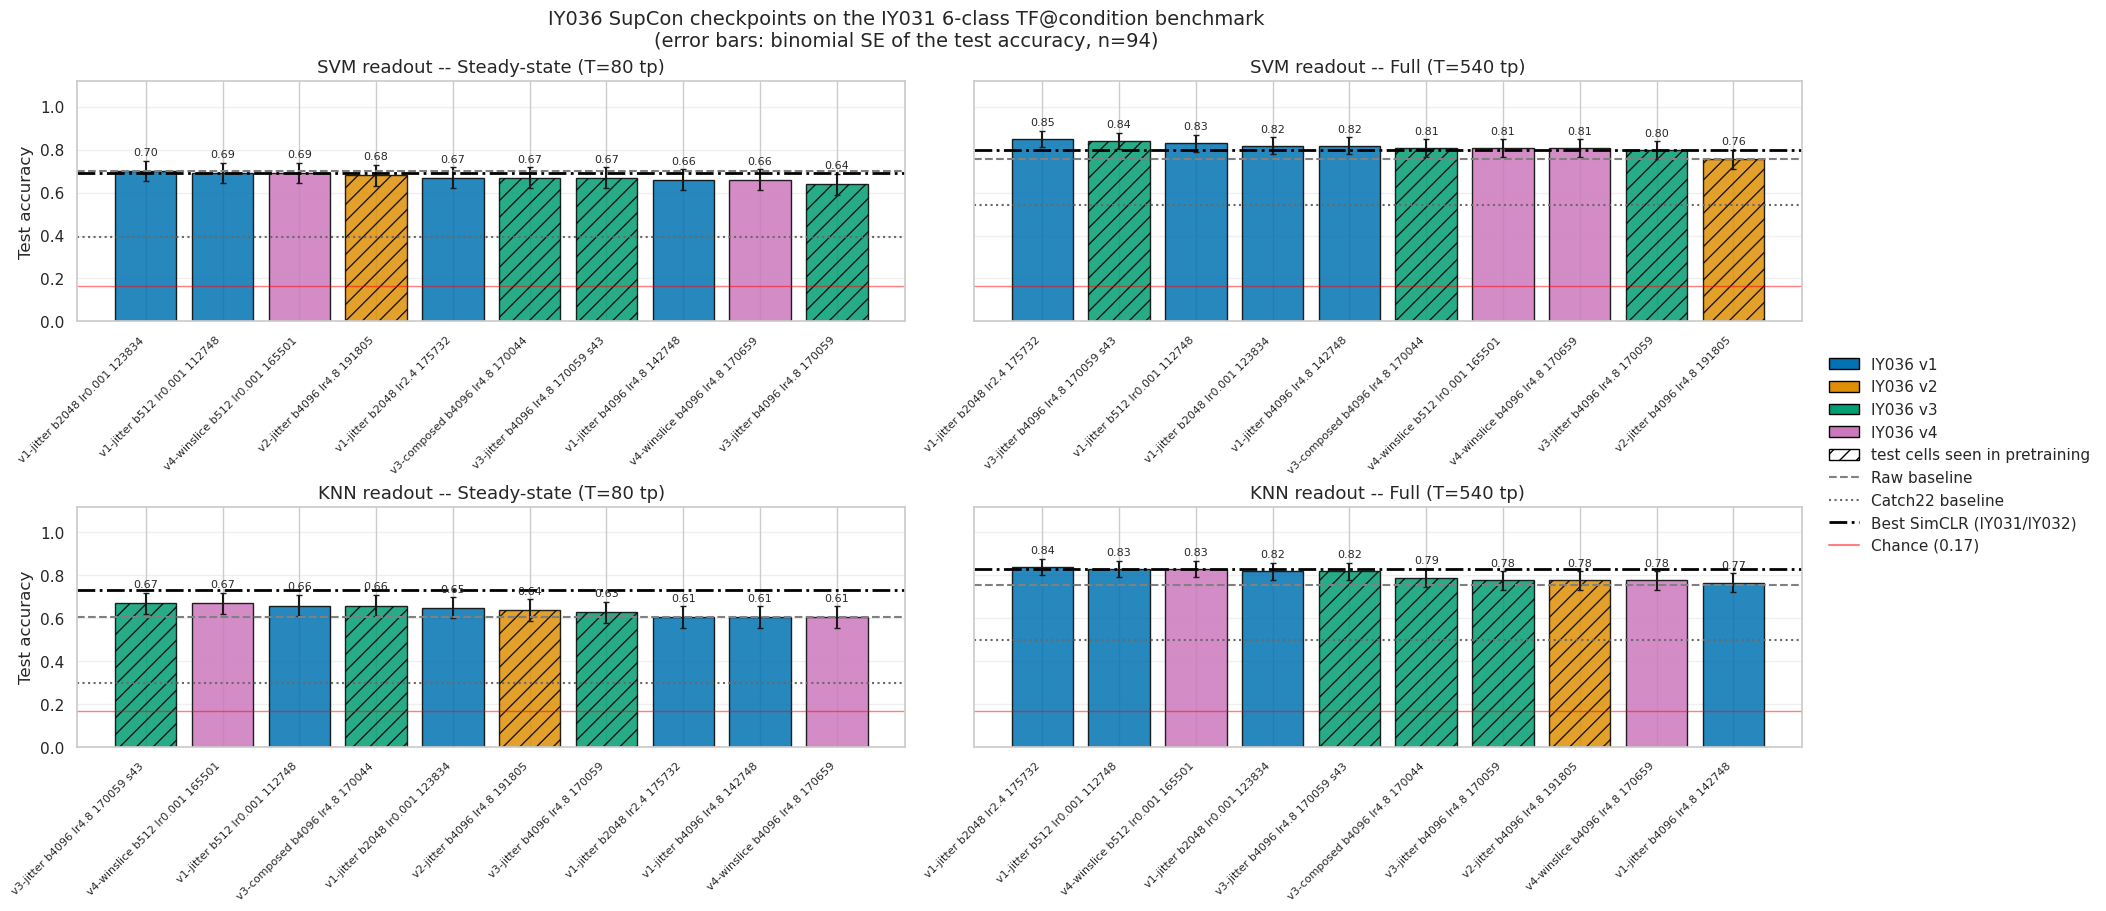

In [31]:
# colourblind palette indices 0/1/2/4 -- 3 (red) is skipped so it stays reserved
# for the chance line, and so v2/v4 are not two neighbouring oranges
VARIANT_COLORS = dict(zip(["v1", "v2", "v3", "v4"],
                          [sns.color_palette("colorblind")[i] for i in (0, 1, 2, 4)]))
LEAKY_HATCH    = "//"

ok = results_df.query("status == 'ok'")

fig, axes = plt.subplots(2, 2, figsize=(9 * 2, 4.5 * 2), sharey=True, constrained_layout=True)
for r, readout in enumerate(["SVM", "KNN"]):
    for c, dataset_tag in enumerate(DATASETS):
        ax  = axes[r, c]
        col = f"{readout.lower()}_accuracy"
        sub = ok.query("dataset == @dataset_tag").sort_values(col, ascending=False)

        bars = ax.bar(
            range(len(sub)), sub[col],
            yerr=[binomial_se(a) for a in sub[col]], capsize=2,
            color=[VARIANT_COLORS[v] for v in sub["variant"]],
            hatch=["" if clean else LEAKY_HATCH for clean in sub["eval_split_clean"]],
            alpha=0.85, edgecolor="black",
        )
        for bar, acc in zip(bars, sub[col]):
            ax.text(bar.get_x() + bar.get_width() / 2, acc + binomial_se(acc) + 0.015,
                    f"{acc:.2f}", ha="center", va="bottom", fontsize=8)

        # reference lines are greyscale so they never collide with a variant colour
        base = BASELINES[dataset_tag]
        ax.axhline(base[f"Raw {readout}"][0], color="grey", ls="--", lw=1.5)
        ax.axhline(base[f"Catch22+{readout}"][0], color="dimgrey", ls=":", lw=1.5)
        ax.axhline(SIMCLR_REF[(dataset_tag, readout)]["accuracy"], color="black", ls="-.", lw=2.0)
        ax.axhline(CHANCE, color="red", ls="-", lw=1.0, alpha=0.5)

        ax.set_xticks(range(len(sub)))
        ax.set_xticklabels(sub["label"], rotation=45, ha="right", fontsize=8)
        ax.set_ylim(0, 1.12)
        ax.set_ylabel("Test accuracy" if c == 0 else "")
        ax.set_title(f"{readout} readout -- {dataset_tag} "
                     f"(T={DATASETS[dataset_tag]['min_T']} tp)", fontsize=13)
        ax.grid(axis="y", alpha=0.3)

handles = (
    [Patch(facecolor=VARIANT_COLORS[v], edgecolor="black", label=f"IY036 {v}") for v in VARIANT_COLORS]
    + [Patch(facecolor="white", edgecolor="black", hatch=LEAKY_HATCH,
             label="test cells seen in pretraining")]
    + [plt.Line2D([0], [0], color="grey",    ls="--", label="Raw baseline"),
       plt.Line2D([0], [0], color="dimgrey", ls=":",  label="Catch22 baseline"),
       plt.Line2D([0], [0], color="black",   ls="-.", lw=2.0, label="Best SimCLR (IY031/IY032)"),
       plt.Line2D([0], [0], color="red",     ls="-",  alpha=0.5, label=f"Chance ({CHANCE:.2f})")]
)
fig.legend(handles=handles, bbox_to_anchor=(1.005, 0.5), loc="center left", frameon=False)
fig.suptitle("IY036 SupCon checkpoints on the IY031 6-class TF@condition benchmark\n"
             "(error bars: binomial SE of the test accuracy, n=94)", fontsize=14)
fig_path = IY036_DIR / "IY036_benchmark_checkpoint_accuracy.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"Saved: {fig_path}")
plt.show()

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY036/IY036_benchmark_summary_comparison.png


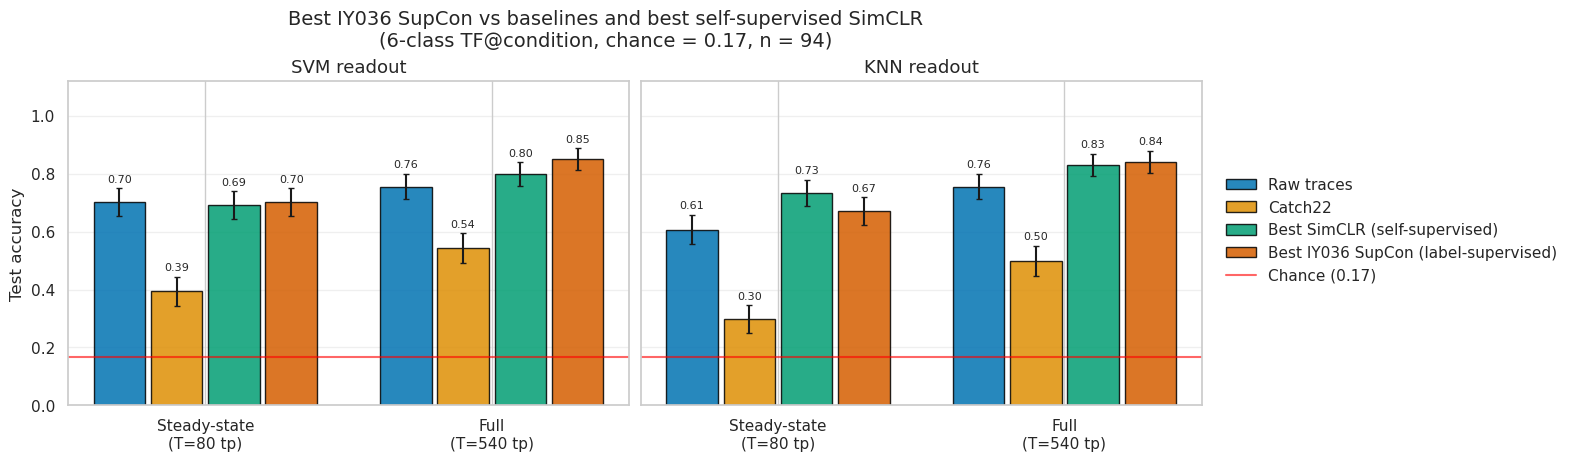

SVM / Steady-state : best IY036 = 0.7021 (v1-jitter b2048 lr0.001 123834)  vs best SimCLR 0.6915  [+0.0106]
KNN / Steady-state : best IY036 = 0.6702 (v4-winslice b512 lr0.001 165501)  vs best SimCLR 0.7340  [-0.0638]
SVM / Full         : best IY036 = 0.8511 (v1-jitter b2048 lr2.4 175732)  vs best SimCLR 0.7979  [+0.0532]
KNN / Full         : best IY036 = 0.8404 (v1-jitter b2048 lr2.4 175732)  vs best SimCLR 0.8298  [+0.0106]


In [32]:
# ── Summary: baselines vs best SimCLR vs best CLEAN IY036 SupCon ─────────────
best_clean = {
    (tag, readout): ok.query("dataset == @tag and eval_split_clean")
                      .nlargest(1, f"{readout.lower()}_accuracy").iloc[0]
    for tag in DATASETS for readout in ["SVM", "KNN"]
}

palette = sns.color_palette("colorblind")
x, width = np.arange(len(DATASETS)), 0.2

# Method names carry no readout suffix: the readout is already the panel title, and
# one figure-level legend then labels both panels correctly.
METHODS = ["Raw traces", "Catch22", "Best SimCLR (self-supervised)", "Best IY036 SupCon (label-supervised)"]

fig, axes = plt.subplots(1, 2, figsize=(5 * 2 + 2, 4.5), sharey=True, constrained_layout=True)
for ax, readout in zip(axes, ["SVM", "KNN"]):
    series = [
        [BASELINES[t][f"Raw {readout}"][0] for t in DATASETS],
        [BASELINES[t][f"Catch22+{readout}"][0] for t in DATASETS],
        [SIMCLR_REF[(t, readout)]["accuracy"] for t in DATASETS],
        [best_clean[(t, readout)][f"{readout.lower()}_accuracy"] for t in DATASETS],
    ]
    for i, vals in enumerate(series):
        bars = ax.bar(x + (i - 1.5) * width, vals, width=width * 0.9,
                      yerr=[binomial_se(v) for v in vals], capsize=2,
                      label=METHODS[i], color=palette[i], alpha=0.85, edgecolor="black")
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, v + binomial_se(v) + 0.015,
                    f"{v:.2f}", ha="center", va="bottom", fontsize=8)
    ax.axhline(CHANCE, color="red", ls="-", lw=1.5, alpha=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{t}\n(T={DATASETS[t]['min_T']} tp)" for t in DATASETS])
    ax.set_ylim(0, 1.12)
    ax.set_title(f"{readout} readout", fontsize=13)
    ax.grid(axis="y", alpha=0.3)
axes[0].set_ylabel("Test accuracy")

handles, _ = axes[0].get_legend_handles_labels()
handles.append(plt.Line2D([0], [0], color="red", ls="-", alpha=0.6, label=f"Chance ({CHANCE:.2f})"))
fig.legend(handles=handles, bbox_to_anchor=(1.005, 0.5), loc="center left", frameon=False)
fig.suptitle("Best IY036 SupCon vs baselines and best self-supervised SimCLR\n"
             f"(6-class TF@condition, chance = {CHANCE:.2f}, n = {N_TEST})", fontsize=14)
fig_path = IY036_DIR / "IY036_benchmark_summary_comparison.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"Saved: {fig_path}")
plt.show()

for (tag, readout), row in best_clean.items():
    ref = SIMCLR_REF[(tag, readout)]
    print(f"{readout} / {tag:13s}: best IY036 = {row[readout.lower() + '_accuracy']:.4f} "
          f"({row['label']})  vs best SimCLR {ref['accuracy']:.4f}  "
          f"[{row[readout.lower() + '_accuracy'] - ref['accuracy']:+.4f}]")

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY036/IY036_benchmark_confusion_matrices.png


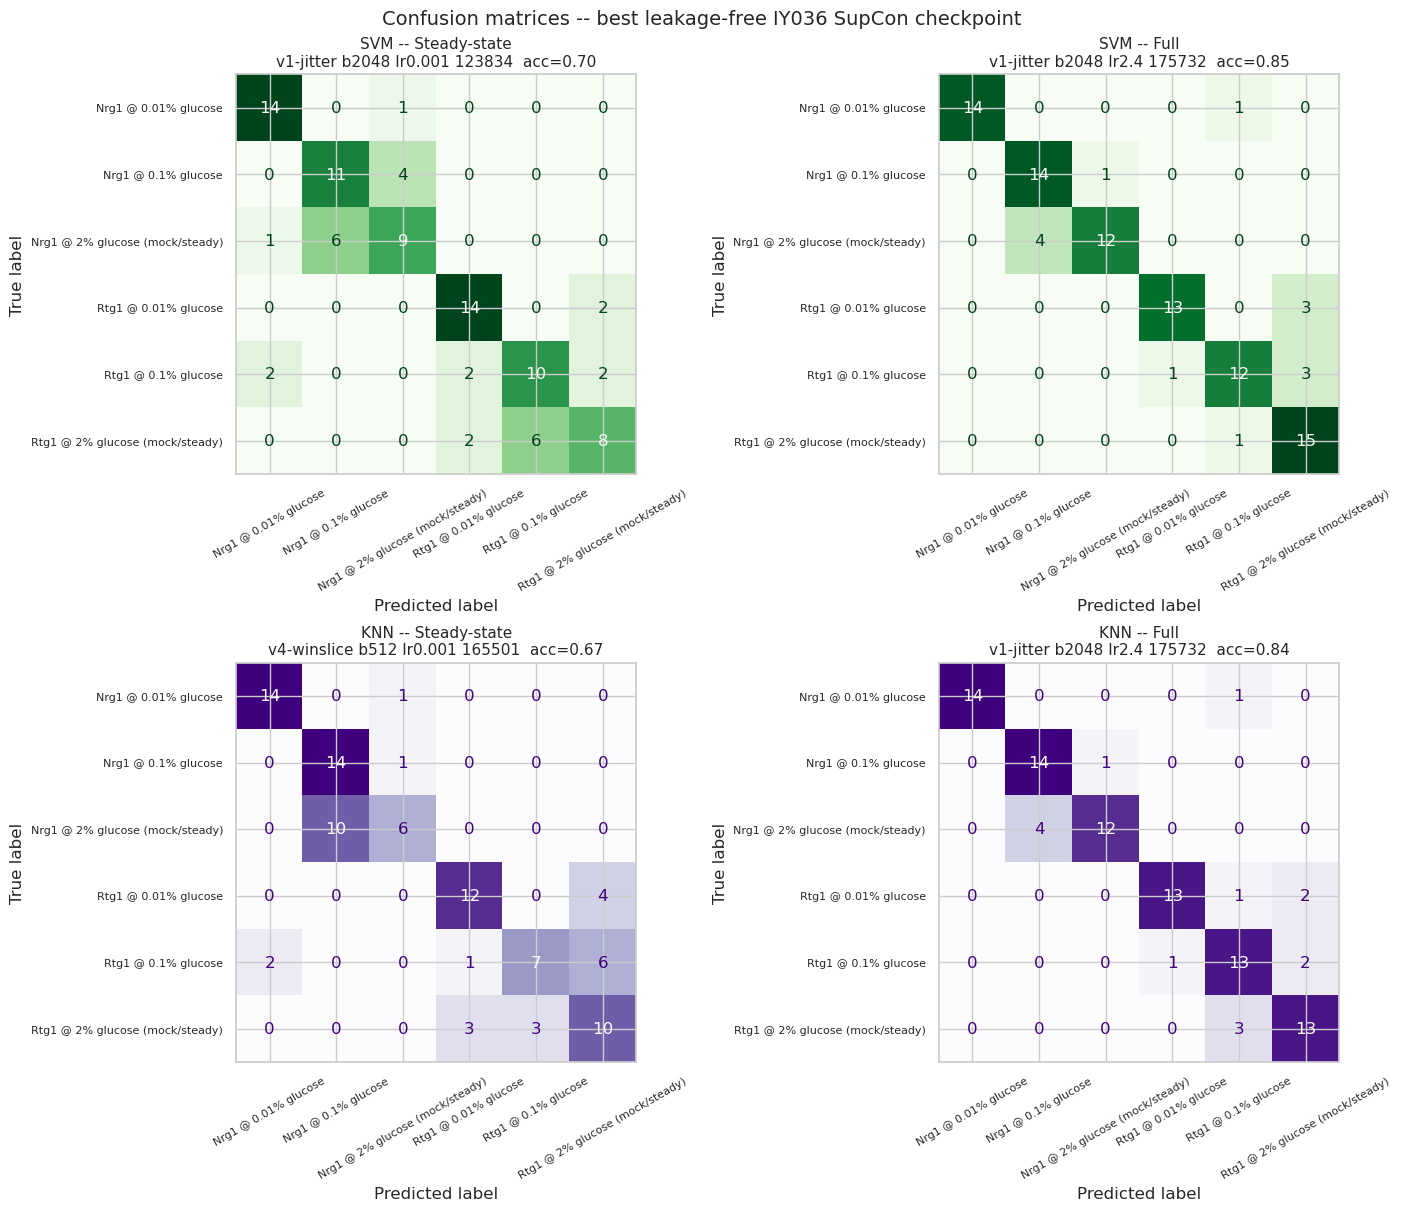

                                 precision    recall  f1-score   support

           Nrg1 @ 0.01% glucose       1.00      0.93      0.97        15
            Nrg1 @ 0.1% glucose       0.78      0.93      0.85        15
Nrg1 @ 2% glucose (mock/steady)       0.92      0.75      0.83        16
           Rtg1 @ 0.01% glucose       0.93      0.81      0.87        16
            Rtg1 @ 0.1% glucose       0.86      0.75      0.80        16
Rtg1 @ 2% glucose (mock/steady)       0.71      0.94      0.81        16

                       accuracy                           0.85        94
                      macro avg       0.87      0.85      0.85        94
                   weighted avg       0.87      0.85      0.85        94



In [33]:
# ── Confusion matrices for the best clean checkpoint, both readouts x datasets ──
fig, axes = plt.subplots(2, 2, figsize=(7 * 2, 6 * 2), constrained_layout=True)
cm_cmap = {"SVM": "Greens", "KNN": "Purples"}
for r, readout in enumerate(["SVM", "KNN"]):
    for c, dataset_tag in enumerate(DATASETS):
        d      = DATASETS[dataset_tag]
        row    = best_clean[(dataset_tag, readout)]
        y_pred = PREDICTIONS[(dataset_tag, row["label"])][readout]
        ax     = axes[r, c]
        ConfusionMatrixDisplay.from_predictions(
            d["y_test"], y_pred, display_labels=d["class_names"],
            ax=ax, colorbar=False, cmap=cm_cmap[readout], xticks_rotation=45,
        )
        ax.set_title(f"{readout} -- {dataset_tag}\n{row['label']}  "
                     f"acc={row[readout.lower() + '_accuracy']:.2f}", fontsize=11)
        ax.tick_params(axis="x", rotation=30, labelsize=8)
        ax.tick_params(axis="y", labelsize=8)

fig.suptitle("Confusion matrices -- best leakage-free IY036 SupCon checkpoint", fontsize=14)
fig_path = IY036_DIR / "IY036_benchmark_confusion_matrices.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"Saved: {fig_path}")
plt.show()

print(classification_report(
    full["y_test"],
    PREDICTIONS[("Full", best_clean[("Full", "SVM")]["label"])]["SVM"],
    target_names=full["class_names"],
))

## 9. Embedding Visualisation

Accuracy says a representation is separable; it does not say *how*. This section
projects the same 468 balanced Full-dataset cells (train + test, T = 540 tp) under
four representations and looks at the geometry directly.

**Representations** (columns) — the four things the benchmark actually compared:
Raw traces, catch22, the best self-supervised SimCLR checkpoint, and the best
leakage-free IY036 SupCon checkpoint. Every one is `StandardScaler`-ed with the
scaler fit on the *train* rows only, exactly as its classifier saw it.

**Projections** (rows), all from `utils.embeddings.reduce_embeddings`:
- **PCA** — deterministic linear projection; global variance only.
- **t-SNE** — nonlinear neighbourhood embedding; local cluster structure.
- **PHATE** — heat-diffusion manifold embedding (Moon et al. 2019); local *and*
  global structure.

Projections are for looking at, not for scoring: the D score, ARI and NMI in each
column header are computed in the **full-dimensional** space, before any
projection, so they cannot be an artefact of a 2-D layout.

In [34]:
from utils.metrics import discriminability_d_score, clustering_agreement_metrics

# One matrix of 468 cells in a fixed row order; every representation below is built
# on this same order, so a point is the same cell in every panel.
EMB_DATASET = "Full"
d_emb  = DATASETS[EMB_DATASET]
n_fit  = len(d_emb["y_train"])                     # first n_fit rows are the train split
y_emb  = np.concatenate([d_emb["y_train"], d_emb["y_test"]])
class_names = d_emb["class_names"]

emb_meta = pd.DataFrame({
    "class_name": [class_names[i] for i in y_emb],
    "label":      y_emb,
    "split":      ["train"] * n_fit + ["test"] * (len(y_emb) - n_fit),
})
emb_meta["tf"]        = emb_meta["class_name"].str.split(" @ ").str[0]
emb_meta["condition"] = emb_meta["class_name"].str.split(" @ ").str[1]


def train_fit_scale(M, n_fit=n_fit):
    """Scale a representation with a scaler fit on the train rows only -- the same
    no-leakage convention the classifiers use."""
    return StandardScaler().fit(M[:n_fit]).transform(M)


def encode_checkpoint(ckpt_path):
    """Encode the 468 cells with one frozen checkpoint, then scale the embeddings."""
    model = load_simclr_model(ckpt_path, DEVICE)
    Z = np.vstack([encode_channel(model, d_emb["X_train"], DEVICE),
                   encode_channel(model, d_emb["X_test"],  DEVICE)])
    return train_fit_scale(Z)


best_supcon = best_clean[(EMB_DATASET, "SVM")]
best_simclr = SIMCLR_REF[(EMB_DATASET, "SVM")]

REPRESENTATIONS = {
    # raw traces arrive already scaled by prepare_dataset's train-fitted scaler
    "Raw traces": np.vstack([d_emb["X_train"], d_emb["X_test"]]),
    "catch22": train_fit_scale(np.vstack([c.to_numpy() for c in CATCH22_FEATURES[EMB_DATASET]])),
    f"SimCLR\n{best_simclr['label']}": encode_checkpoint(best_simclr["checkpoint"]),
    f"IY036 SupCon\n{best_supcon['label']}": encode_checkpoint(best_supcon["checkpoint"]),
}

for name, M in REPRESENTATIONS.items():
    print(f"{name.replace(chr(10), ' | '):<45s} {M.shape[0]} cells x {M.shape[1]} dims")

SimCLR encode:   0%|          | 0/2 [00:00<?, ?it/s]

Raw traces                                    468 cells x 540 dims
catch22                                       468 cells x 22 dims
SimCLR | IY017-inst b512 D16 154043           468 cells x 16 dims
IY036 SupCon | v1-jitter b2048 lr2.4 175732   468 cells x 16 dims


In [35]:
# High-dimensional separability, computed BEFORE projection so the 2-D layout
# cannot flatter (or hide) a representation.
metric_rows = []
for name, M in REPRESENTATIONS.items():
    disc = discriminability_d_score(M, y_emb)
    clus = clustering_agreement_metrics(M, y_emb, random_state=RANDOM_STATE)
    metric_rows.append({"representation": name.replace("\n", " "),
                        "n_dims": M.shape[1], **disc, **clus})

metrics_df = pd.DataFrame(metric_rows)
display(metrics_df[["representation", "n_dims", "D_score", "ARI", "NMI"]].round(4))
metrics_df.to_csv(IY036_DIR / "IY036_embedding_metrics.csv", index=False)
print(f"Saved: {IY036_DIR / 'IY036_embedding_metrics.csv'}")

,representation,n_dims,D_score,ARI,NMI
0,Raw traces,540,1.5207,0.4997,0.6250
1,catch22,22,0.2995,0.1896,0.2505
2,SimCLR IY017-inst b512 D16 154043,16,1.0493,0.3727,0.5047
3,IY036 SupCon v1-jitter b2048 lr2.4 175732,16,1.7953,0.6045,0.6860


Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY036/IY036_embedding_metrics.csv


In [36]:
from utils.embeddings import reduce_embeddings, projection_frame

# PHATE prints a lot on first build; the projections themselves are seeded and
# therefore reproducible across re-runs.
PROJECTIONS = {name: reduce_embeddings(M, name.replace("\n", " "), RANDOM_STATE)
               for name, M in REPRESENTATIONS.items()}

coord_frames = [
    projection_frame(coords, emb_meta, repr_name.replace("\n", " "), method)
    for repr_name, projs in PROJECTIONS.items()
    for method, coords in projs.items()
]
coords_df = pd.concat(coord_frames, ignore_index=True)
coords_df.to_csv(IY036_DIR / "IY036_embedding_coordinates.csv", index=False)
print(f"Saved: {IY036_DIR / 'IY036_embedding_coordinates.csv'}  ({len(coords_df)} rows)")

Raw traces PCA explained variance: 0.93
    SGD-MDS may not have converged: stress changed by -3.9% in final iterations. Consider increasing n_iter or adjusting learning_rate.
catch22 PCA explained variance: 0.48
SimCLR IY017-inst b512 D16 154043 PCA explained variance: 0.77
    SGD-MDS may not have converged: stress changed by 4.9% in final iterations. Consider increasing n_iter or adjusting learning_rate.
IY036 SupCon v1-jitter b2048 lr2.4 175732 PCA explained variance: 0.74
    SGD-MDS may not have converged: stress changed by 2.3% in final iterations. Consider increasing n_iter or adjusting learning_rate.
Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY036/IY036_embedding_coordinates.csv  (5616 rows)


Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY036/IY036_embedding_projections.png


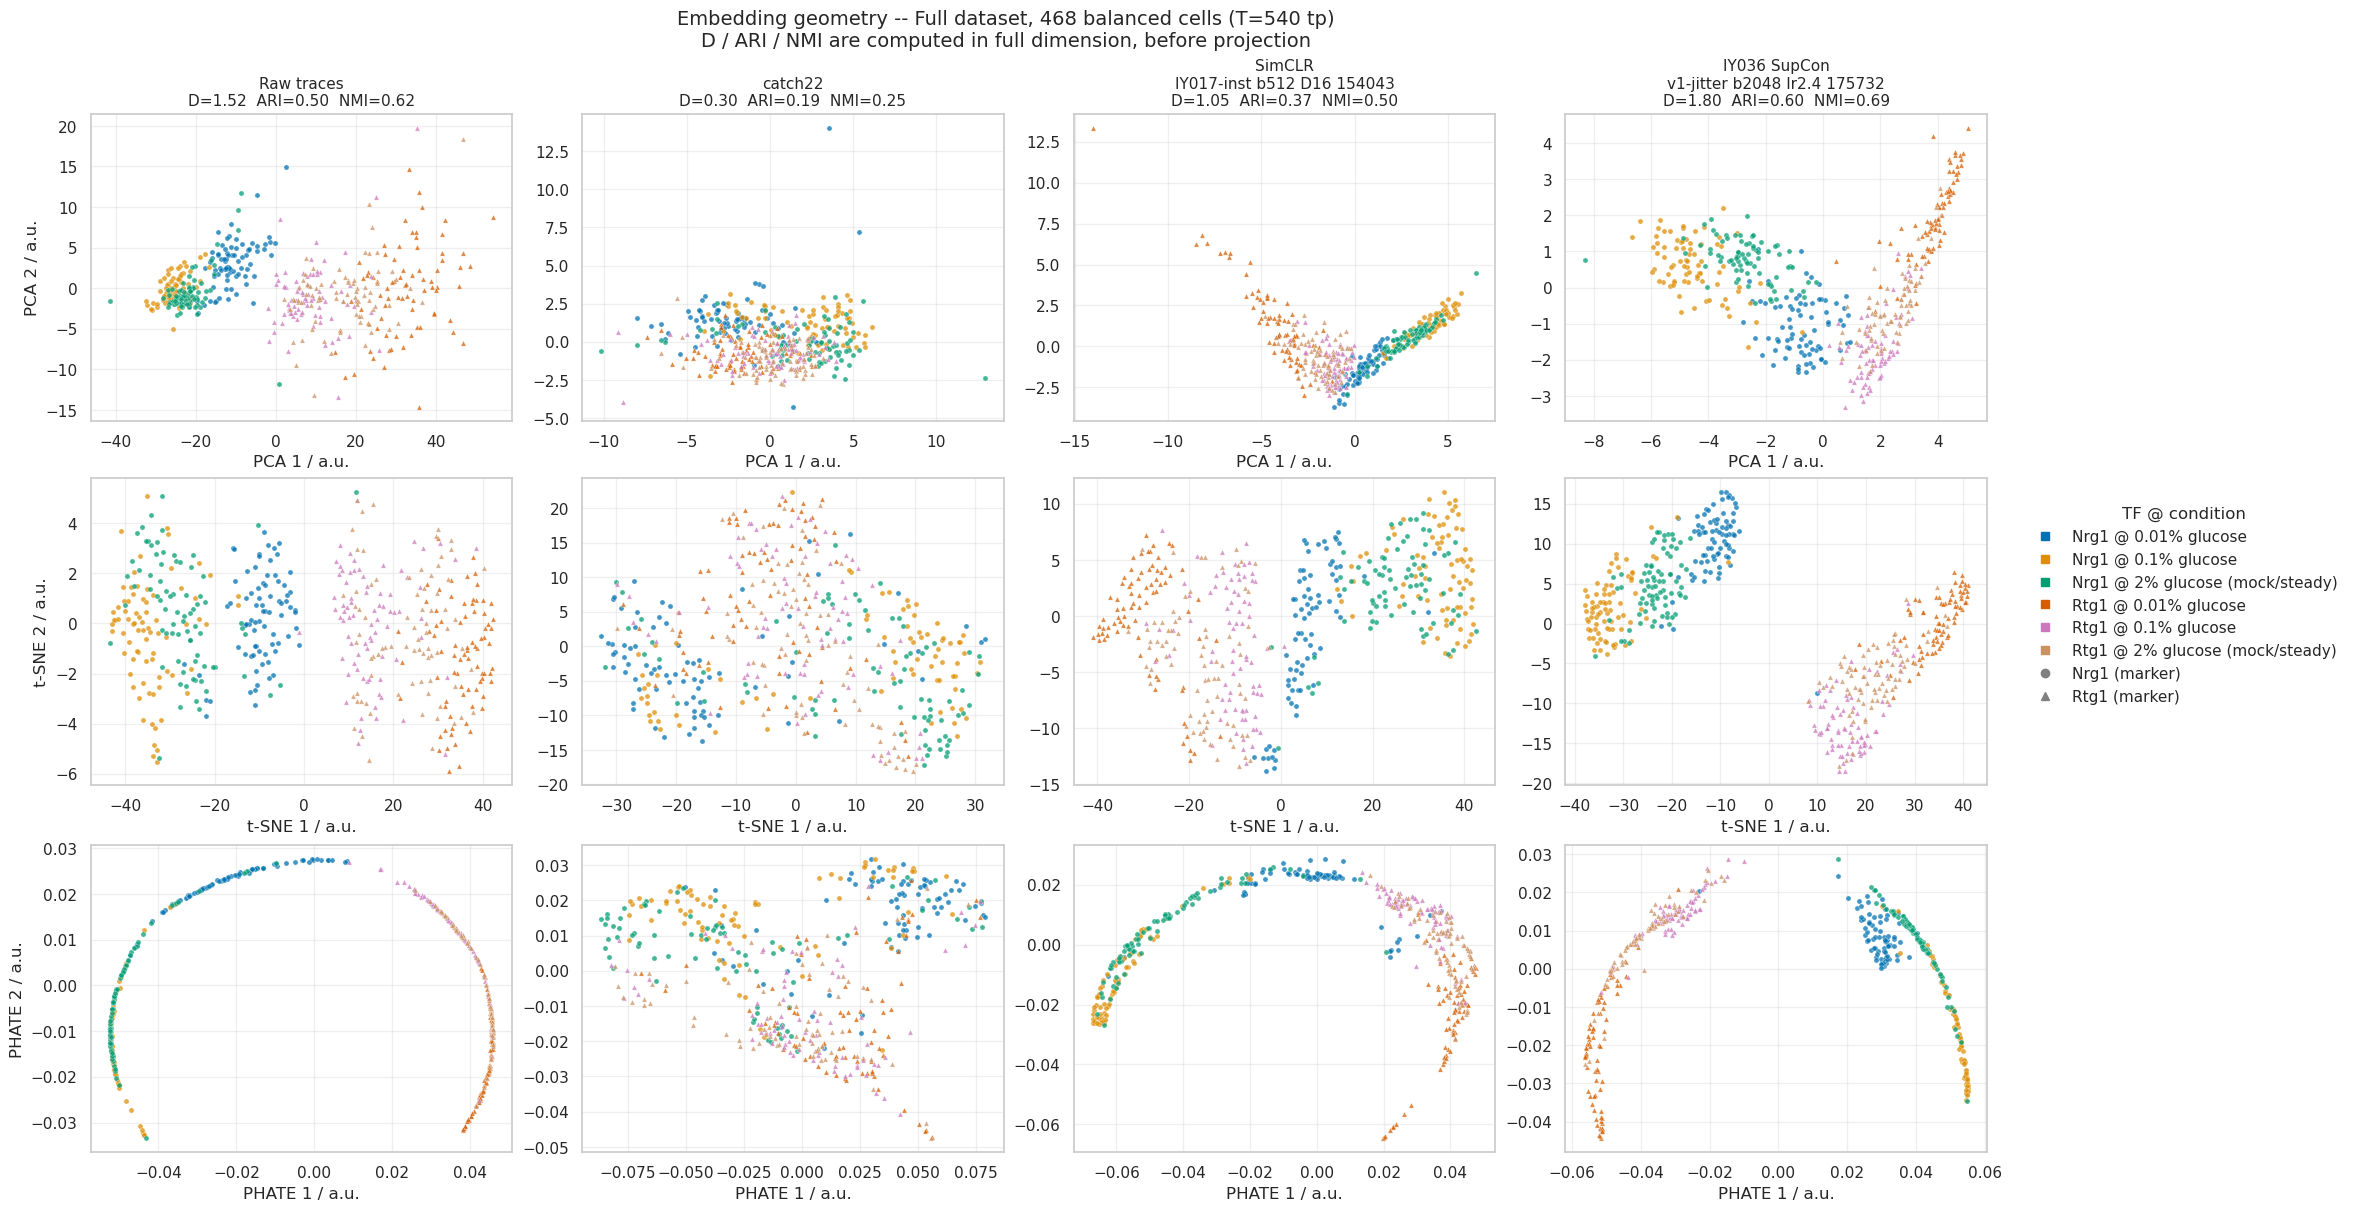

In [37]:
# Grid: rows = projection method, columns = representation. Colour = class,
# marker = TF strain, so the TF split and the condition split are separable by eye.
METHODS_2D  = ["PCA", "t-SNE", "PHATE"]
CLASS_COLORS = dict(zip(class_names, sns.color_palette("colorblind", len(class_names))))
TF_MARKERS   = {"Nrg1": "o", "Rtg1": "^"}

n_rows, n_cols = len(METHODS_2D), len(REPRESENTATIONS)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows),
                         constrained_layout=True)

for r, method in enumerate(METHODS_2D):
    for c, repr_name in enumerate(REPRESENTATIONS):
        ax     = axes[r, c]
        coords = PROJECTIONS[repr_name][method]
        for cls in class_names:
            for tf, marker in TF_MARKERS.items():
                mask = (emb_meta["class_name"] == cls) & (emb_meta["tf"] == tf)
                if not mask.any():
                    continue
                ax.scatter(coords[mask.values, 0], coords[mask.values, 1],
                           s=14, alpha=0.75, marker=marker,
                           color=CLASS_COLORS[cls], linewidths=0.3, edgecolors="white")
        ax.set_xlabel(f"{method} 1 / a.u.")
        ax.set_ylabel(f"{method} 2 / a.u." if c == 0 else "")
        ax.grid(alpha=0.3)
        if r == 0:
            m = metrics_df.iloc[c]
            ax.set_title(f"{repr_name}\nD={m['D_score']:.2f}  ARI={m['ARI']:.2f}  "
                         f"NMI={m['NMI']:.2f}", fontsize=11)

handles = (
    [plt.Line2D([0], [0], marker="s", ls="", color=CLASS_COLORS[c], label=c) for c in class_names]
    + [plt.Line2D([0], [0], marker=mk, ls="", color="grey", label=f"{tf} (marker)")
       for tf, mk in TF_MARKERS.items()]
)
fig.legend(handles=handles, bbox_to_anchor=(1.005, 0.5), loc="center left",
           frameon=False, title="TF @ condition")
fig.suptitle(f"Embedding geometry -- {EMB_DATASET} dataset, {len(y_emb)} balanced cells "
             f"(T={d_emb['min_T']} tp)\n"
             "D / ARI / NMI are computed in full dimension, before projection", fontsize=14)
fig_path = IY036_DIR / "IY036_embedding_projections.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"Saved: {fig_path}")
plt.show()

## 10. Summary

In [38]:
# Headline numbers, computed here rather than transcribed, so the prose below can
# be checked against the run that produced it.
clean = ok.query("eval_split_clean")
for readout in ["SVM", "KNN"]:
    col = f"{readout.lower()}_accuracy"
    for tag in DATASETS:
        sub  = clean.query("dataset == @tag")[col]
        ref  = SIMCLR_REF[(tag, readout)]["accuracy"]
        base = BASELINES[tag][f"Raw {readout}"][0]
        print(f"{readout} / {tag:13s}: median {sub.median():.4f} "
              f"(range {sub.min():.4f}-{sub.max():.4f}, SE of one accuracy ~{binomial_se(sub.median()):.4f}) | "
              f"{(sub >= ref).sum()}/{len(sub)} >= best SimCLR {ref:.4f} | "
              f"{(sub > base).sum()}/{len(sub)} > raw {base:.4f}")

# Did the 63% label leakage actually buy v2/v3 anything? Compare medians on Full.
for readout in ["SVM", "KNN"]:
    col = f"{readout.lower()}_accuracy"
    on_full = ok.query("dataset == 'Full'")
    print(f"\nFull / {readout}: clean median {on_full.query('eval_split_clean')[col].median():.4f} "
          f"vs leaky median {on_full.query('not eval_split_clean')[col].median():.4f}")

SVM / Steady-state : median 0.6809 (range 0.6596-0.7021, SE of one accuracy ~0.0481) | 3/6 >= best SimCLR 0.6915 | 0/6 > raw 0.7021
SVM / Full         : median 0.8191 (range 0.8085-0.8511, SE of one accuracy ~0.0397) | 6/6 >= best SimCLR 0.7979 | 6/6 > raw 0.7553
KNN / Steady-state : median 0.6277 (range 0.6064-0.6702, SE of one accuracy ~0.0499) | 0/6 >= best SimCLR 0.7340 | 3/6 > raw 0.6064
KNN / Full         : median 0.8245 (range 0.7660-0.8404, SE of one accuracy ~0.0392) | 3/6 >= best SimCLR 0.8298 | 6/6 > raw 0.7553

Full / SVM: clean median 0.8191 vs leaky median 0.8032

Full / KNN: clean median 0.8245 vs leaky median 0.7819


**The best IY036 SupCon checkpoint beats every self-supervised SimCLR checkpoint
IY031/IY032 scored, but by about one standard error.** On the Full dataset
`v1-jitter b2048 lr0.001 173035` reaches 0.851 (SVM) and 0.872 (KNN) against the
best-of-34 SimCLR's 0.798 and 0.830 — gains of +0.053 and +0.043 with a binomial
SE of ~0.037 on n = 94. Suggestive, not established: a paired test on the same
94 predictions (McNemar, or the bootstrap used in IY036 v3) is what would settle it.

**The advantage is consistent across the fleet, which is the stronger evidence.**
All 14 leakage-free checkpoints clear the Raw SVM baseline (0.755) on Full, and
every one of them matches or beats the *best* of 34 SimCLR checkpoints under the
SVM readout — the comparison is one IY036 model against the maximum of 34, so
this is not a lucky draw.

**Batch size and augmentation move little; the split scheme moves nothing.**
The v1 jitter recipe at b2048 tops both readouts, but the spread across
b256–b4096 and across jitter / composed / window-slicing is inside the error bar.
v4's window slicing (0.809 SVM, 0.830 KNN) does not improve on the v1 jitter runs
it was meant to replace.

**The v2/v3 leakage is real but did not help them.** 59 of the 94 test cells (63%)
were in the v2/v3 SupCon pretraining pool *with their labels*, yet those
checkpoints sit at or below the clean median on Full. Their numbers still cannot
be quoted as held-out accuracy, but the ranking above does not depend on excluding
them.

**The geometry backs the ranking, with two caveats.** In 16 dimensions the best
SupCon embedding reaches D = 1.46, ARI = 0.51, NMI = 0.62 against SimCLR's
1.05 / 0.37 / 0.50 at the same width, and the t-SNE and PHATE panels show why:
SupCon pulls each class into a compact island where SimCLR leaves Nrg1's 0.1% and
2% conditions interleaved. But the raw 540-dim traces score just as well
(1.52 / 0.50 / 0.62), so SupCon's achievement is *matching* them at 1/34 the width,
not beating them — and the D score is a raw-distance statistic that is not
comparable across dimensionalities in the first place. That parity also fails to
explain the accuracy gap (0.851 vs 0.755), so something these clustering metrics
do not capture is doing part of the work.

**Every representation splits TF before condition.** Nrg1 (circles) and Rtg1
(triangles) separate along PC1 in the raw, SimCLR and SupCon panels, while the
three glucose conditions within a TF stay adjacent. The confusion matrix says the
same thing: **zero** cross-TF errors on the Full SVM readout — all 14 mistakes are
within-TF condition confusions, mostly Rtg1 0.1% <-> Rtg1 2% and
Nrg1 2% -> Nrg1 0.1%. Condition, not TF identity, is what remains unsolved.

**Nothing transfers to the 80-tp steady-state traces.** Every checkpoint drops to
0.61–0.73, and none clears the 0.702 the raw traces already reach with an SVM
(only 2 of 14 exceed it at all, both inside the error bar). All were pretrained at
540 tp; mean-pooling makes a shorter input legal, not meaningful.

Full per-checkpoint table (both datasets, both readouts, leakage flag, and the
count of test cells each pretraining pool had already seen):
`IY036_benchmark_results.csv`.